In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('cleaned_online_retail.csv')

In [4]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [7]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [10]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


<Axes: xlabel='InvoiceDate'>

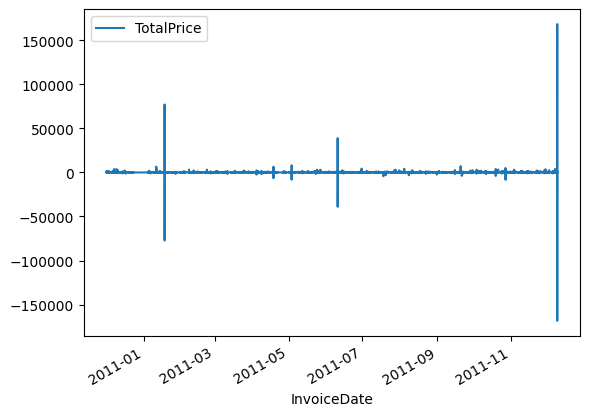

In [15]:
df.plot(x='InvoiceDate', y='TotalPrice')

### Stationary Test

In [18]:
from statsmodels.tsa.stattools import adfuller

In [19]:
result = adfuller(df['TotalPrice'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])


ADF Statistic: -71.081447
p-value: 0.000000


As p-value is less than 0.05 it means, I reject the null hypothesis (which says the data is non-stationary), therefore my sales data is stationary.

In [34]:
from statsmodels.tsa.stattools import kpss
result2 = kpss(df['TotalPrice'])
print("KPSS Statistic:", result2[0])
print("p-value:", result2[1])

KPSS Statistic: 1.0718297467873674
p-value: 0.01


C:\Users\Pratham\AppData\Local\Temp\ipykernel_2632\3603526497.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result2 = kpss(df['TotalPrice'])


As p-value is less than 0.05, it means that we are rejecting the null-hypithesis(i.e data is stationary). So therefore the data is non-stationary.

### Checking the data is sorted or not

In [26]:
df.iloc[[1,4000,10000,20000],:]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4000,536846,22179,SET 10 LIGHTS NIGHT OWL,1,2010-12-02 19:59:00,6.75,14573.0,United Kingdom,6.75
10000,537465,22328,ROUND SNACK BOXES SET OF 4 FRUITS,6,2010-12-07 10:32:00,2.95,17735.0,United Kingdom,17.70
20000,538843,22728,ALARM CLOCK BAKELIKE PINK,2,2010-12-14 13:18:00,3.75,16033.0,United Kingdom,7.50


In [29]:
data=np.log(df['TotalPrice'])
data=data.diff()

C:\Users\Pratham\AppData\Roaming\Python\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Pratham\AppData\Roaming\Python\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: >

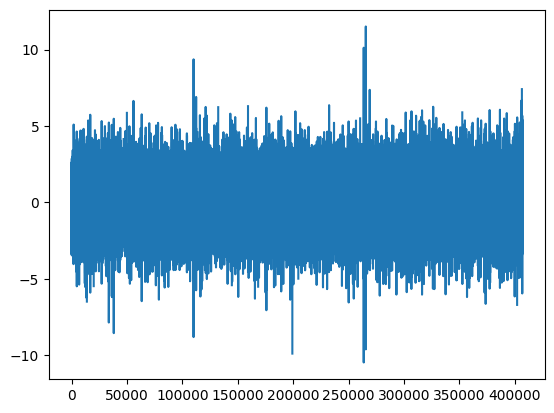

In [30]:
data.plot()